In [2]:
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

print("train:", train.shape)
print("test :", test.shape)
train.head()

train: (5634, 40)
test : (1409, 39)


,Churn,customerID,Contract,OnlineBackup,MonthlyCharges,InternetService,StreamingTV,DeviceProtection,MultipleLines,TotalCharges,...,service_count,tenure_band,monthly_charge_band,bill_per_month,bill_pressure,household_score,profile_code,row_variant,dup_sig,col_order_key
0,0,8033-ATFAS,Month-to-month,No,60.61,DSL,Yes,Yes,No,2494.92,...,3,long,high,60.04,1.50,2,long_Month-to-month_Mailed check,shadow,TFAS_shadow,6917
1,0,6833-JMZYP,Month-to-month,No,94.00,Fiber optic,Yes,Yes,No,1505.45,...,4,mid,very_high,100.36,5.88,0,mid_Month-to-month_Credit card (automatic),base,MZYP_base,2482
2,0,4537-CIBHB,One year,No internet service,20.25,No,No internet service,No internet service,No,172.35,...,0,short,lower_mid,19.15,2.02,2,short_One year_Mailed check,base,IBHB_base,4145
3,0,1752-OZXFY,One year,No,59.80,DSL,Yes,No,No,3561.15,...,3,very_long,high,59.35,0.98,1,very_long_One year_Mailed check,base,ZXFY_base,3214
4,0,7622-FWGEW,Two year,Yes,85.65,DSL,Yes,Yes,No,4824.45,...,7,very_long,very_high,86.15,1.50,1,very_long_Two year_Bank transfer (automatic),base,WGEW_base,5801


In [3]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Churn                5634 non-null   int64  
 1   customerID           5634 non-null   str    
 2   Contract             5634 non-null   str    
 3   OnlineBackup         5536 non-null   str    
 4   MonthlyCharges       5634 non-null   float64
 5   InternetService      5634 non-null   str    
 6   StreamingTV          5634 non-null   str    
 7   DeviceProtection     5536 non-null   str    
 8   MultipleLines        5634 non-null   str    
 9   TotalCharges         5634 non-null   float64
 10  Dependents           5634 non-null   str    
 11  gender               5634 non-null   str    
 12  PaperlessBilling     5634 non-null   str    
 13  PhoneService         5634 non-null   str    
 14  TechSupport          5536 non-null   str    
 15  Partner              5634 non-null   str    
 16 

In [4]:
faltantes = train.isnull().sum()
print(faltantes[faltantes > 0].sort_values(ascending=False))

OnlineBackup        98
DeviceProtection    98
TechSupport         98
OnlineSecurity      98
PaymentMethod       73
support_depth       73
dtype: int64


In [5]:
print(list(train.columns))


['Churn', 'customerID', 'Contract', 'OnlineBackup', 'MonthlyCharges', 'InternetService', 'StreamingTV', 'DeviceProtection', 'MultipleLines', 'TotalCharges', 'Dependents', 'gender', 'PaperlessBilling', 'PhoneService', 'TechSupport', 'Partner', 'tenure', 'PaymentMethod', 'SeniorCitizen', 'StreamingMovies', 'OnlineSecurity', 'SeniorCitizenLabel', 'PartnerLabel', 'DependentsLabel', 'PhoneServiceLabel', 'PaperlessLabel', 'ServiceFamily', 'PaymentFamily', 'support_depth', 'stream_depth', 'service_count', 'tenure_band', 'monthly_charge_band', 'bill_per_month', 'bill_pressure', 'household_score', 'profile_code', 'row_variant', 'dup_sig', 'col_order_key']


In [6]:
# ¿los 98 faltantes de los servicios caen en las mismas filas?
cols_servicios = ['OnlineBackup', 'DeviceProtection', 'TechSupport', 'OnlineSecurity']
print(train[cols_servicios].isnull().all(axis=1).sum(), "filas con los 4 servicios faltantes a la vez")

# ¿PaymentMethod y support_depth faltan juntos?
print(train[['PaymentMethod', 'support_depth']].isnull().all(axis=1).sum(), "filas con ambos faltantes a la vez")

98 filas con los 4 servicios faltantes a la vez
73 filas con ambos faltantes a la vez


In [7]:
# para evaluar las columnas sospechosas
for col in ['profile_code', 'row_variant', 'dup_sig', 'col_order_key']:
    print(f"\n{col}: {train[col].nunique()} valores únicos")
    print(train[col].head(3).tolist())


profile_code: 58 valores únicos
['long_Month-to-month_Mailed check', 'mid_Month-to-month_Credit card (automatic)', 'short_One year_Mailed check']

row_variant: 2 valores únicos
['shadow', 'base', 'base']

dup_sig: 5599 valores únicos
['TFAS_shadow', 'MZYP_base', 'IBHB_base']

col_order_key: 5634 valores únicos
[6917, 2482, 4145]


In [8]:
# ¿cuántas base vs shadow?
print(train['row_variant'].value_counts())

# ¿las shadow son copias de las base? comparemos un cliente
# extraemos el "código base" del customerID (últimos 4 chars antes del variant)
print("\n--- ejemplo: buscamos si hay pares base/shadow ---")
print(train[['customerID', 'row_variant', 'Churn', 'tenure', 'MonthlyCharges']].head(10))

row_variant
base      5334
shadow     300
Name: count, dtype: int64

--- ejemplo: buscamos si hay pares base/shadow ---
   customerID row_variant  Churn  tenure  MonthlyCharges
0  8033-ATFAS      shadow      0      40           60.61
1  6833-JMZYP        base      0      15           94.00
2  4537-CIBHB        base      0       9           20.25
3  1752-OZXFY        base      0      60           59.80
4  7622-FWGEW        base      0      56           85.65
5  1078-TDCRN        base      0       3           30.75
6  4967-WPNCF        base      0      71           60.17
7  4559-UWIHT        base      0      14           82.65
8  6614-YWYSC        base      0      61           25.00
9  4664-NJCMS        base      0      33           59.55


In [9]:
# comparamos las shadow contra las base buscando duplicados en las columnas de datos
# (ignorando ids)
cols_id = ['customerID', 'dup_sig', 'col_order_key', 'row_variant', 'profile_code']
cols_datos = [c for c in train.columns if c not in cols_id]

# ¿cuántas filas están duplicadas si miramos solo los datos (sin ids)?
dups = train.duplicated(subset=cols_datos, keep=False).sum()
print(f"{dups} filas tienen datos idénticos a otra fila (ignorando IDs)")

# a ver si las shadow tienden a ser las duplicadas
print("\nDuplicados por tipo de fila:")
train['es_dup'] = train.duplicated(subset=cols_datos, keep=False)
print(train.groupby('row_variant')['es_dup'].sum())

24 filas tienen datos idénticos a otra fila (ignorando IDs)

Duplicados por tipo de fila:
row_variant
base      24
shadow     0
Name: es_dup, dtype: int64


In [10]:
# 1. ¿las shadow tienen una tasa de churn distinta a las base?
#    (si son muy distintas, podrían ser ruido que confunde)
print("Tasa de churn por tipo de fila:")
print(train.groupby('row_variant')['Churn'].mean())

# 2. ¿el test también tiene filas shadow? 
print("\n¿row_variant existe en test?", 'row_variant' in test.columns)
if 'row_variant' in test.columns:
    print(test['row_variant'].value_counts())

Tasa de churn por tipo de fila:
row_variant
base      0.267904
shadow    0.220000
Name: Churn, dtype: float64

¿row_variant existe en test? True
row_variant
base      1331
shadow      78
Name: count, dtype: int64


## Análisis de calidad de datos

### Valores faltantes
Se detectaron faltantes en 6 columnas con un patrón **sistemático** (no aleatorio):
- OnlineBackup, DeviceProtection, TechSupport, OnlineSecurity: 98 faltantes,
  ausentes en las **mismas 98 filas** (los 4 servicios faltan juntos).
- PaymentMethod y support_depth: 73 faltantes, también en las mismas filas.

El patrón indica un mecanismo común de ausencia, no aleatorio.

### Auditoría de variables sin valor predictivo
- `col_order_key`: identificador único por fila (5634 valores únicos) → **se descarta**
  (un árbol podría memorizarlo y sobreajustar).
- `dup_sig`: identificador derivado (customerID + row_variant), 5599 únicos → **se descarta**.
- `profile_code`: concatenación de tenure_band + Contract + PaymentMethod (58 únicos),
  redundante con columnas existentes → **se descarta**.

### Filas "shadow" (row_variant)
El dataset contiene 300 filas marcadas como `shadow` (5.3%) además de 5334 `base`.
Investigación:
- **No son duplicados**: solo 24 filas tienen datos idénticos a otra, y todas son `base`.
  Las shadow tienen datos propios.
- **Tasa de churn similar**: base 26.8% vs shadow 22.0% → comportamiento comparable.
- **El test también contiene shadow** en proporción equivalente (78/1409 = 5.5%).

**Decisión**: se conservan las filas shadow, dado que el conjunto de test las incluye
en la misma proporción. Entrenar sin ellas degradaría la predicción sobre ese subconjunto
del test. La columna `row_variant` no se usará como variable predictiva (es una marca de
procedencia, no una característica del cliente).

In [11]:
# 1. ¿qué valores tienen las columnas de servicios? (para entender el "Unknown")
print(train['OnlineBackup'].value_counts(dropna=False))

# 2. ¿el test también tiene faltantes en estas columnas?
print("\nFaltantes en TEST:")
faltantes_test = test.isnull().sum()
print(faltantes_test[faltantes_test > 0].sort_values(ascending=False))

OnlineBackup
No                     2454
Yes                    1886
No internet service    1196
NaN                      98
Name: count, dtype: int64

Faltantes en TEST:
OnlineBackup        25
DeviceProtection    25
TechSupport         25
PaymentMethod       25
OnlineSecurity      25
support_depth       25
dtype: int64


In [12]:
# columnas categóricas con faltantes -> imputar con "Unknown"
cols_cat_faltantes = ['OnlineBackup', 'DeviceProtection', 'TechSupport', 
                      'OnlineSecurity', 'PaymentMethod']

for col in cols_cat_faltantes:
    train[col] = train[col].fillna("Unknown")
    test[col]  = test[col].fillna("Unknown")

# verificamos que ya no queden faltantes en esas columnas
print("Faltantes restantes en train:")
print(train[cols_cat_faltantes].isnull().sum())
print("\nFaltantes restantes en test:")
print(test[cols_cat_faltantes].isnull().sum())

Faltantes restantes en train:
OnlineBackup        0
DeviceProtection    0
TechSupport         0
OnlineSecurity      0
PaymentMethod       0
dtype: int64

Faltantes restantes en test:
OnlineBackup        0
DeviceProtection    0
TechSupport         0
OnlineSecurity      0
PaymentMethod       0
dtype: int64


In [13]:
# ¿qué pinta tiene support_depth?
print("Valores de support_depth:")
print(train['support_depth'].value_counts(dropna=False).sort_index())

print("\nTipo de dato:", train['support_depth'].dtype)

# ¿se relaciona con las columnas de soporte? veamos algunas filas
print("\nRelación con servicios de soporte:")
print(train[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'support_depth']].head(8))

Valores de support_depth:
support_depth
0.0    2200
1.0    1184
2.0    1071
3.0     755
4.0     351
NaN      73
Name: count, dtype: int64

Tipo de dato: float64

Relación con servicios de soporte:
        OnlineSecurity         OnlineBackup     DeviceProtection  \
0                   No                   No                  Yes   
1                   No                   No                  Yes   
2  No internet service  No internet service  No internet service   
3                  Yes                   No                   No   
4                  Yes                  Yes                  Yes   
5                   No                  Yes                   No   
6                  Yes                  Yes                  Yes   
7                   No                  Yes                  Yes   

           TechSupport  support_depth  
0                   No            1.0  
1                   No            1.0  
2  No internet service            0.0  
3                   No        

In [14]:
servicios_soporte = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']

# recalculamos: contamos cuántos están en "Yes" (igual en train y test)
train['support_depth'] = (train[servicios_soporte] == "Yes").sum(axis=1)
test['support_depth']  = (test[servicios_soporte] == "Yes").sum(axis=1)

# verificamos que no queden faltantes y que coincida con los valores originales
print("Faltantes en support_depth → train:", train['support_depth'].isnull().sum(),
      "| test:", test['support_depth'].isnull().sum())
print("\nDistribución recalculada (train):")
print(train['support_depth'].value_counts().sort_index())

Faltantes en support_depth → train: 0 | test: 0

Distribución recalculada (train):
support_depth
0    2292
1    1191
2    1060
3     740
4     351
Name: count, dtype: int64


### Tratamiento de valores faltantes

El conjunto de **test presenta los mismos faltantes** que el train (25 por columna,
en las mismas 6 columnas), por lo que la estrategia debe funcionar en ambos conjuntos.
Esto **descarta la eliminación de filas**: no es posible borrar registros del test, ya
que se requiere predecir los 1409 clientes.

**Variables categóricas** (OnlineBackup, DeviceProtection, TechSupport, OnlineSecurity,
PaymentMethod): se imputó el faltante como una **categoría propia "Unknown"**, en lugar
de imputar con la moda. Justificación:
- El patrón de ausencia es sistemático (no aleatorio), por lo que asumir que esas filas
  "son como la mayoría" (moda) sería incorrecto.
- No se inventan datos: el modelo puede aprender si la ausencia misma se asocia al churn.
- Es coherente con el dataset, que ya trata estados especiales como categoría explícita
  (p. ej. "No internet service").

**Variable derivada `support_depth`**: se confirmó que es el **conteo de servicios de
soporte contratados** (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport en "Yes").
En lugar de imputar sus 73 faltantes, se **recalculó** desde las columnas originales tras
la imputación, garantizando consistencia y eliminando los faltantes de forma controlada.

**Resultado**: el dataset queda sin valores faltantes en train ni test.

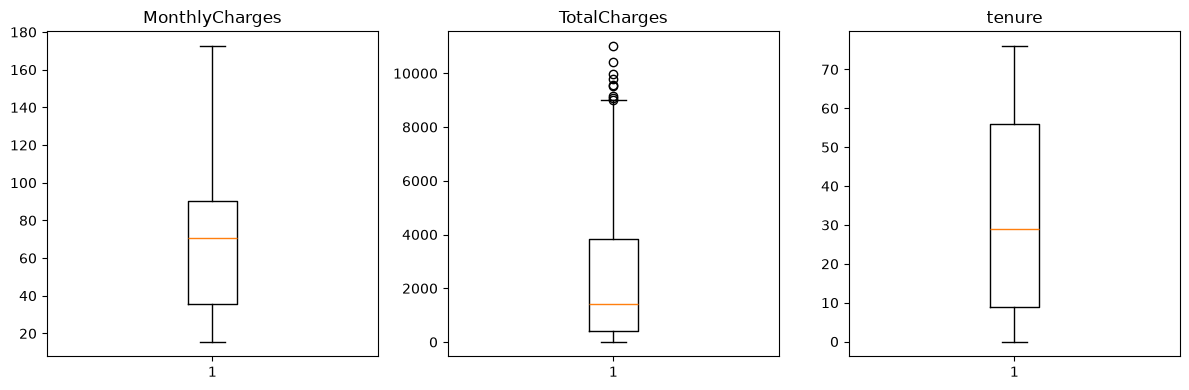

,MonthlyCharges,TotalCharges,tenure
count,5634.000000,5634.000000,5634.000000
mean,65.555327,2306.957102,32.665247
std,30.920103,2284.463787,24.584380
min,15.650000,16.270000,0.000000
1%,19.100000,19.926600,1.000000
5%,19.650000,49.032500,1.000000
25%,35.562500,404.550000,9.000000
50%,70.600000,1412.085000,29.000000
75%,90.450000,3845.182500,56.000000
95%,109.100000,6932.007500,72.000000


In [15]:
# Análisis de outliers en las numéricas originales clave (Clase 2: boxplot + cuantiles)
# Solo TRAIN: la calidad de datos se evalúa mirando el train, no el test.
import matplotlib.pyplot as plt

num_cols = ["MonthlyCharges", "TotalCharges", "tenure"]

# Un boxplot por variable (escalas muy distintas → subplots separados, no uno solo)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, num_cols):
    ax.boxplot(train[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Cuantiles para leer el boxplot con números (colas y extremos)
train[num_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

### Análisis de valores atípicos (numéricas clave)

Se analizaron `MonthlyCharges`, `TotalCharges` y `tenure` mediante **boxplot** y
**cuantiles** (Clase 2).

- **MonthlyCharges** y **tenure**: sin atípicos fuera de los bigotes (1.5·IQR).
  `tenure` está acotada por el tope de permanencia (~76 meses) y `MonthlyCharges`
  presenta una cola suave sin saltos. Valores plausibles en todo el rango.
- **TotalCharges**: la regla 1.5·IQR marca un conjunto de valores altos
  (máx ≈ 11011 vs. p99 ≈ 8159). **No son errores**: `TotalCharges` es un
  acumulado ≈ `MonthlyCharges` × `tenure`, por lo que un cliente con cuota alta
  y antigüedad máxima genera naturalmente un total elevado. La cola larga a la
  derecha es esperable en un producto de dos variables acotado en 0; la regla
  del IQR (pensada para distribuciones simétricas) sobre-marca esa cola.

**Decisión: no se tratan los atípicos; se conservan todas las filas.** Motivos:
(1) los valores extremos son clientes legítimos de alto gasto y larga
permanencia —un segmento relevante para el churn—, no ruido a limpiar;
(2) el tratamiento de escala es **dependiente del modelo**: los modelos de árbol
(árbol, RF, boosting) son robustos a valores extremos, y la sensibilidad de la
regresión logística se resuelve mediante **escalado** (paso siguiente), no
eliminando datos.

In [16]:
# Columnas que no son atributos del cliente -> drop
cols_a_descartar = [
    'customerID',    # identificador único, no predictivo
    'col_order_key', # ID de fila, 5634 valores únicos
    'dup_sig',       # derivado de customerID + row_variant
    'profile_code',  # concatenación de tenure_band + Contract + PaymentMethod
    'row_variant',   # marca de procedencia (base/shadow), no atributo
    'es_dup',        # columna auxiliar creada en el análisis, no predictiva
]

train = train.drop(columns=cols_a_descartar)
test  = test.drop(columns=[c for c in cols_a_descartar if c in test.columns])

print("Columnas restantes en train:", train.shape[1])
print("Columnas restantes en test :", test.shape[1])
print(list(train.columns))

Columnas restantes en train: 35
Columnas restantes en test : 34
['Churn', 'Contract', 'OnlineBackup', 'MonthlyCharges', 'InternetService', 'StreamingTV', 'DeviceProtection', 'MultipleLines', 'TotalCharges', 'Dependents', 'gender', 'PaperlessBilling', 'PhoneService', 'TechSupport', 'Partner', 'tenure', 'PaymentMethod', 'SeniorCitizen', 'StreamingMovies', 'OnlineSecurity', 'SeniorCitizenLabel', 'PartnerLabel', 'DependentsLabel', 'PhoneServiceLabel', 'PaperlessLabel', 'ServiceFamily', 'PaymentFamily', 'support_depth', 'stream_depth', 'service_count', 'tenure_band', 'monthly_charge_band', 'bill_per_month', 'bill_pressure', 'household_score']


In [17]:
# Columnas numéricas que requieren escalado para modelos sensibles a la escala
# (regresión logística, MLP). Los modelos de árbol (DT, RF, Boosting) no lo necesitan.
cols_numericas = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'support_depth', 'stream_depth', 'service_count',
    'bill_per_month', 'bill_pressure', 'household_score'
]

# Vista previa: rango de cada variable (justifica por qué escalar es relevante)
train[cols_numericas].agg(['min', 'max', 'mean', 'std']).T.round(2)

,min,max,mean,std
tenure,0.00,76.00,32.67,24.58
MonthlyCharges,15.65,172.53,65.56,30.92
TotalCharges,16.27,11011.19,2306.96,2284.46
support_depth,0.00,4.00,1.23,1.28
stream_depth,0.00,2.00,0.77,0.85
service_count,0.00,8.00,3.34,2.34
bill_per_month,13.78,121.40,64.77,30.18
bill_pressure,0.26,80.85,5.74,8.69
household_score,0.00,2.00,0.78,0.82


## Cierre Tarea 1 — Preprocesamiento

### Descarte de columnas sin valor predictivo

Se identificaron y eliminaron 6 columnas antes del modelado:

| Columna | Motivo |
|---|---|
| `customerID` | Identificador único del cliente, no atributo predictivo |
| `col_order_key` | ID de fila (5634 valores únicos); un árbol podría memorizarlo y sobreajustar |
| `dup_sig` | Derivado de customerID + row_variant, sin información propia |
| `profile_code` | Concatenación de tenure_band + Contract + PaymentMethod: redundante con originales |
| `row_variant` | Marca de procedencia (base/shadow), no característica del cliente |
| `es_dup` | Variable auxiliar de análisis, no predictiva |

### Inconsistencia detectada: SeniorCitizen vs SeniorCitizenLabel

Durante la auditoría de columnas Label (Tarea 2) se identificó una inconsistencia
en el dataset original: 400 filas presentan contradicción entre `SeniorCitizen`
(0/1 numérica) y `SeniorCitizenLabel` (non_senior/senior). Dado que `SeniorCitizen`
es la columna original y ya está codificada numéricamente, se conserva ella y se
descarta `SeniorCitizenLabel`.

### Transformación de variables: estrategia de escalado

Las variables numéricas presentan rangos muy dispares (`TotalCharges`: 16–11011;
`support_depth`: 0–4). La **regresión logística** es sensible a esta diferencia:
sin normalizar, las variables de mayor rango dominan los coeficientes sin reflejar
su importancia real. Los modelos de árbol no tienen esta sensibilidad, ya que sus
splits son ordinales.

**Decisión:** aplicar `StandardScaler` dentro del `Pipeline` de cada modelo que
lo requiera (regresión logística y MLP). El ajuste del scaler se realiza
exclusivamente sobre el conjunto de entrenamiento en cada fold de validación,
evitando que información del test influya en la transformación.

El efecto del escalado sobre el desempeño de la regresión logística se evalúa
en Tarea 3 comparando métricas con y sin esta transformación.

In [18]:
# Verificamos si las *Label duplican información de sus originales
pares = [
    ('SeniorCitizen',    'SeniorCitizenLabel'),
    ('Partner',          'PartnerLabel'),
    ('Dependents',       'DependentsLabel'),
    ('PhoneService',     'PhoneServiceLabel'),
    ('PaperlessBilling', 'PaperlessLabel'),
]

for orig, label in pares:
    n_combos = train.groupby([orig, label]).size().reset_index()
    print(f"\n{orig} ↔ {label}:")
    print(n_combos.to_string(index=False))


SeniorCitizen ↔ SeniorCitizenLabel:
 SeniorCitizen SeniorCitizenLabel    0
             0         non_senior 4370
             0             senior   54
             1         non_senior  346
             1             senior  864

Partner ↔ PartnerLabel:
Partner PartnerLabel    0
     No       single 2899
    Yes    partnered 2735

Dependents ↔ DependentsLabel:
Dependents DependentsLabel    0
        No            none 3948
       Yes      dependents 1686

PhoneService ↔ PhoneServiceLabel:
PhoneService PhoneServiceLabel    0
          No           no_line  542
         Yes       active_line 5092

PaperlessBilling ↔ PaperlessLabel:
PaperlessBilling PaperlessLabel    0
              No          paper 2315
             Yes      paperless 3319


In [19]:
# Las *Label duplican sus originales (verificado arriba).
# SeniorCitizenLabel además es inconsistente con SeniorCitizen (400 filas contradictorias)
# → se descartan todas las *Label; se conservan los originales.
cols_label = ['SeniorCitizenLabel', 'PartnerLabel', 'DependentsLabel',
              'PhoneServiceLabel', 'PaperlessLabel']

train = train.drop(columns=cols_label)
test  = test.drop(columns=cols_label)

print("Columnas train:", train.shape[1], "| test:", test.shape[1])

Columnas train: 30 | test: 29


In [20]:
# ¿Qué valores tienen las columnas de familia?
print("ServiceFamily:", train['ServiceFamily'].nunique(), "valores únicos")
print(train['ServiceFamily'].value_counts(), "\n")

print("PaymentFamily:", train['PaymentFamily'].nunique(), "valores únicos")
print(train['PaymentFamily'].value_counts())

ServiceFamily: 9 valores únicos
ServiceFamily
Fiber optic_Month-to-month    1705
DSL_Month-to-month             967
No_Two year                    520
DSL_Two year                   515
DSL_One year                   455
Fiber optic_One year           444
No_Month-to-month              413
Fiber optic_Two year           327
No_One year                    288
Name: count, dtype: int64 

PaymentFamily: 8 valores únicos
PaymentFamily
Electronic check_Yes             1398
Mailed check_No                   764
Bank transfer (automatic)_Yes     720
Credit card (automatic)_Yes       703
Credit card (automatic)_No        539
Bank transfer (automatic)_No      528
Mailed check_Yes                  498
Electronic check_No               484
Name: count, dtype: int64


In [21]:
# Confirmamos que ServiceFamily se puede reconstruir exactamente desde las originales
check_sf = (train['InternetService'] + "_" + train['Contract']) == train['ServiceFamily']
check_pf = (train['PaymentMethod'] + "_" + train['PaperlessBilling']) == train['PaymentFamily']

print("ServiceFamily reconstruible desde originales:", check_sf.all())
print("PaymentFamily reconstruible desde originales:", check_pf.all())

train = train.drop(columns=['ServiceFamily', 'PaymentFamily'])
test  = test.drop(columns=['ServiceFamily', 'PaymentFamily'])
print("\nColumnas restantes — train:", train.shape[1], "| test:", test.shape[1])

ServiceFamily reconstruible desde originales: True
PaymentFamily reconstruible desde originales: False

Columnas restantes — train: 28 | test: 27


In [22]:
# ¿tenure_band y monthly_charge_band son solo bins de sus originales?
print("tenure_band vs tenure:")
print(train.groupby('tenure_band')['tenure'].agg(['min','max']))

print("\nmonthly_charge_band vs MonthlyCharges:")
print(train.groupby('monthly_charge_band')['MonthlyCharges'].agg(['min','max']))

# ¿bill_per_month ≈ TotalCharges / tenure?
train['_check_bpm'] = (train['TotalCharges'] / train['tenure'].replace(0, np.nan)).round(2)
corr_bpm = train['bill_per_month'].corr(train['_check_bpm'])
print(f"\ncorr(bill_per_month, TotalCharges/tenure): {corr_bpm:.4f}")
train.drop(columns=['_check_bpm'], inplace=True)

# ¿stream_depth = StreamingTV=="Yes" + StreamingMovies=="Yes"?
check_sd = ((train['StreamingTV']=='Yes').astype(int) + 
            (train['StreamingMovies']=='Yes').astype(int))
print(f"\nstream_depth reconstruible exacto: {(check_sd == train['stream_depth']).all()}")

# ¿service_count = total de servicios en "Yes"?
servicios = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
             'StreamingTV','StreamingMovies','PhoneService','MultipleLines']
check_sc = (train[servicios] == 'Yes').sum(axis=1)
print(f"service_count reconstruible exacto: {(check_sc == train['service_count']).all()}")

# bill_pressure y household_score: distribución rápida
print("\nbill_pressure — describe:")
print(train['bill_pressure'].describe().round(2))
print("\nhousehold_score — value_counts:")
print(train['household_score'].value_counts().sort_index())

tenure_band vs tenure:
             min  max
tenure_band          
long          22   50
mid           10   26
short          2   14
very_long     46   76
very_short     0    7

monthly_charge_band vs MonthlyCharges:
                       min     max
monthly_charge_band               
high                 46.48  127.03
low                  15.92   37.07
lower_mid            15.65   54.80
mid                  28.68   87.24
very_high            70.00  172.53

corr(bill_per_month, TotalCharges/tenure): 0.9732

stream_depth reconstruible exacto: True
service_count reconstruible exacto: False

bill_pressure — describe:
count    5634.00
mean        5.74
std         8.69
min         0.26
25%         1.24
50%         2.08
75%         5.88
max        80.85
Name: bill_pressure, dtype: float64

household_score — value_counts:
household_score
0    2610
1    1627
2    1397
Name: count, dtype: int64


In [23]:
# 1. ¿household_score = Partner=="Yes" + Dependents=="Yes"?
check_hs = ((train['Partner']=='Yes').astype(int) + 
            (train['Dependents']=='Yes').astype(int))
print("household_score reconstruible (Partner+Dependents):", 
      (check_hs == train['household_score']).all())

# 2. ¿Por qué service_count no reconstruye? Miramos las filas que difieren
servicios = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
             'StreamingTV','StreamingMovies','PhoneService','MultipleLines']
reconstruido = (train[servicios] == 'Yes').sum(axis=1)
diff = train[reconstruido != train['service_count']]
print(f"\nFilas donde service_count no coincide: {len(diff)}")
print("Valores de OnlineBackup en esas filas:")
print(diff['OnlineBackup'].value_counts())

# 3. ¿bill_pressure = MonthlyCharges / tenure?
train['_check_bp'] = (train['MonthlyCharges'] / train['tenure'].replace(0, np.nan)).round(2)
print(f"\ncorr(bill_pressure, MonthlyCharges/tenure): {train['bill_pressure'].corr(train['_check_bp']):.4f}")
train.drop(columns=['_check_bp'], inplace=True)

household_score reconstruible (Partner+Dependents): True

Filas donde service_count no coincide: 1818
Valores de OnlineBackup en esas filas:
OnlineBackup
No internet service    1196
No                      312
Yes                     216
Unknown                  94
Name: count, dtype: int64

corr(bill_pressure, MonthlyCharges/tenure): 0.9591


In [24]:
# Derivadas del host redundantes con las columnas originales → se descartan
cols_derivadas_redundantes = [
    'stream_depth',        # StreamingTV=="Yes" + StreamingMovies=="Yes" exacto
    'household_score',     # Partner=="Yes" + Dependents=="Yes" exacto
    'tenure_band',         # bin de tenure con rangos solapados
    'monthly_charge_band', # bin de MonthlyCharges con rangos solapados
    'bill_per_month',      # corr 0.97 con TotalCharges/tenure
    'bill_pressure',       # corr 0.96 con MonthlyCharges/tenure
]

train = train.drop(columns=cols_derivadas_redundantes)
test  = test.drop(columns=cols_derivadas_redundantes)

print("Columnas finales — train:", train.shape[1], "| test:", test.shape[1])
print(list(train.columns))


Columnas finales — train: 22 | test: 21
['Churn', 'Contract', 'OnlineBackup', 'MonthlyCharges', 'InternetService', 'StreamingTV', 'DeviceProtection', 'MultipleLines', 'TotalCharges', 'Dependents', 'gender', 'PaperlessBilling', 'PhoneService', 'TechSupport', 'Partner', 'tenure', 'PaymentMethod', 'SeniorCitizen', 'StreamingMovies', 'OnlineSecurity', 'support_depth', 'service_count']


In [25]:
# Valores únicos de cada categórica para decidir estrategia de encoding
cols_cat = train.select_dtypes(include='object').columns.tolist()
for col in cols_cat:
    vals = sorted(train[col].unique())
    print(f"{col} ({len(vals)}): {vals}")

Contract (3): ['Month-to-month', 'One year', 'Two year']
OnlineBackup (4): ['No', 'No internet service', 'Unknown', 'Yes']
InternetService (3): ['DSL', 'Fiber optic', 'No']
StreamingTV (3): ['No', 'No internet service', 'Yes']
DeviceProtection (4): ['No', 'No internet service', 'Unknown', 'Yes']
MultipleLines (3): ['No', 'No phone service', 'Yes']
Dependents (2): ['No', 'Yes']
gender (2): ['Female', 'Male']
PaperlessBilling (2): ['No', 'Yes']
PhoneService (2): ['No', 'Yes']
TechSupport (4): ['No', 'No internet service', 'Unknown', 'Yes']
Partner (2): ['No', 'Yes']
PaymentMethod (5): ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check', 'Unknown']
StreamingMovies (3): ['No', 'No internet service', 'Yes']
OnlineSecurity (4): ['No', 'No internet service', 'Unknown', 'Yes']


C:\Users\benja\AppData\Local\Temp\ipykernel_21280\3646359563.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_cat = train.select_dtypes(include='object').columns.tolist()


In [26]:
# 1. Binarias puras → mapeo directo 0/1
binary_cols = ['Dependents', 'PaperlessBilling', 'PhoneService', 'Partner']
for col in binary_cols:
    train[col] = train[col].map({'Yes': 1, 'No': 0})
    test[col]  = test[col].map({'Yes': 1, 'No': 0})

train['gender'] = train['gender'].map({'Male': 1, 'Female': 0})
test['gender']  = test['gender'].map({'Male': 1, 'Female': 0})

# 2. Multi-valor → one-hot encoding (dtype=int para columnas 0/1, no booleanas)
multi_cols = ['Contract', 'OnlineBackup', 'InternetService', 'StreamingTV',
              'DeviceProtection', 'MultipleLines', 'TechSupport',
              'PaymentMethod', 'StreamingMovies', 'OnlineSecurity']

train = pd.get_dummies(train, columns=multi_cols, drop_first=False, dtype=int)

test  = pd.get_dummies(test,  columns=multi_cols, drop_first=False, dtype=int)

# 3. Alineamos test para que tenga exactamente las columnas de train (sin Churn)
cols_train = [c for c in train.columns if c != 'Churn']
test = test.reindex(columns=cols_train, fill_value=0)

print("train:", train.shape)
print("test :", test.shape)
print("\nPrimeras columnas:", list(train.columns[:8]))
print("Últimas columnas:", list(train.columns[-8:]))

train: (5634, 48)
test : (1409, 47)

Primeras columnas: ['Churn', 'MonthlyCharges', 'TotalCharges', 'Dependents', 'gender', 'PaperlessBilling', 'PhoneService', 'Partner']
Últimas columnas: ['PaymentMethod_Unknown', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Unknown', 'OnlineSecurity_Yes']


In [27]:
# Nueva variable 1: costo por servicio contratado
# Clientes que pagan mucho por pocos servicios tienen mayor presión de valor percibido
train['charge_per_service'] = train['MonthlyCharges'] / (train['service_count'] + 1)
test['charge_per_service']  = test['MonthlyCharges']  / (test['service_count']  + 1)

# Nueva variable 2: cliente nuevo (≤12 meses de antigüedad)
# Los primeros 12 meses concentran la mayor tasa de abandono en telecomunicaciones
train['is_new_customer'] = (train['tenure'] <= 12).astype(int)
test['is_new_customer']  = (test['tenure']  <= 12).astype(int)

# Verificación
print("Distribución charge_per_service (train):")
print(train['charge_per_service'].describe().round(2))
print(f"\nClientes nuevos (≤12 meses): {train['is_new_customer'].sum()} ({train['is_new_customer'].mean()*100:.1f}%)")
print(f"Tasa de churn — nuevos: {train[train['is_new_customer']==1]['Churn'].mean():.3f}")
print(f"Tasa de churn — resto:  {train[train['is_new_customer']==0]['Churn'].mean():.3f}")
print(f"\nColumnas finales — train: {train.shape[1]} | test: {test.shape[1]}")

Distribución charge_per_service (train):
count    5634.00
mean       16.92
std         6.05
min         5.30
25%        12.65
50%        16.62
75%        20.15
max        52.16
Name: charge_per_service, dtype: float64

Clientes nuevos (≤12 meses): 1724 (30.6%)
Tasa de churn — nuevos: 0.474
Tasa de churn — resto:  0.173

Columnas finales — train: 50 | test: 49


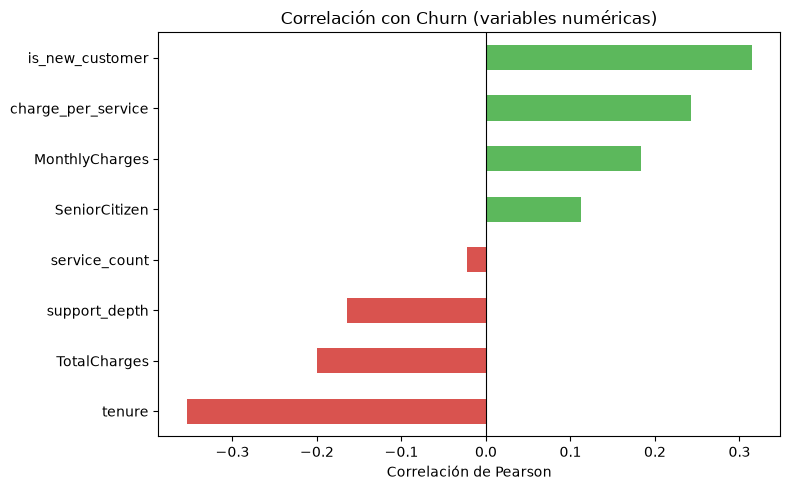

tenure               -0.354
TotalCharges         -0.200
support_depth        -0.164
service_count        -0.023
SeniorCitizen         0.113
MonthlyCharges        0.183
charge_per_service    0.243
is_new_customer       0.315
Name: Churn, dtype: float64


In [28]:
import matplotlib.pyplot as plt

# Correlación de variables numéricas con Churn
cols_num = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
            'support_depth', 'service_count', 'charge_per_service', 'is_new_customer']

corr_churn = train[cols_num + ['Churn']].corr()['Churn'].drop('Churn').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
corr_churn.plot(kind='barh', ax=ax, color=['#d9534f' if v < 0 else '#5cb85c' for v in corr_churn])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación con Churn (variables numéricas)')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print(corr_churn.round(3))

## Tarea 2 — Feature Engineering

### Descarte de columnas derivadas redundantes

El dataset incluía columnas construidas por el host que duplican información
ya presente en las originales. Se verificó cada una con datos antes de descartar:

| Columna | Diagnóstico | Decisión |
|---|---|---|
| `SeniorCitizenLabel`, `PartnerLabel`, `DependentsLabel`, `PhoneServiceLabel`, `PaperlessLabel` | Duplican sus originales (mapeo 1-a-1 verificado) | Descartar |
| `ServiceFamily` | Concatenación exacta de InternetService + Contract | Descartar |
| `PaymentFamily` | Concatenación de PaymentMethod + PaperlessBilling (mismatch en filas imputadas) | Descartar |
| `stream_depth` | Reconstruible exacto: StreamingTV=="Yes" + StreamingMovies=="Yes" | Descartar |
| `household_score` | Reconstruible exacto: Partner=="Yes" + Dependents=="Yes" | Descartar |
| `tenure_band`, `monthly_charge_band` | Bins de variables continuas con rangos solapados entre categorías; la versión continua es estrictamente mejor para árboles y logística con escalado | Descartar |
| `bill_per_month` | Correlación 0.97 con TotalCharges/tenure; redundante dado que ambas originales están presentes | Descartar |
| `bill_pressure` | Correlación 0.96 con MonthlyCharges/tenure; mismo motivo | Descartar |
| `service_count` | No reconstruible desde las columnas de servicios (1818 discrepancias); captura información no derivable | **Conservar** |

### Codificación de variables categóricas

Se aplicaron dos estrategias según la naturaleza de cada variable:

- **Mapeo directo 0/1** para columnas estrictamente binarias (Yes/No):
  `Dependents`, `PaperlessBilling`, `PhoneService`, `Partner`, `gender`.
- **One-hot encoding** para columnas con 3 o más categorías (`Contract`,
  `OnlineBackup`, `InternetService`, `StreamingTV`, `DeviceProtection`,
  `MultipleLines`, `TechSupport`, `PaymentMethod`, `StreamingMovies`,
  `OnlineSecurity`). Se generaron dummies para todas las categorías
  (sin drop_first); la regularización de la regresión logística maneja
  la colinealidad residual.

La codificación se ajustó sobre train y se replicó en test mediante reindex,
garantizando columnas idénticas en ambos conjuntos.

**Resultado:** 49 variables predictoras en el dataset de modelado.

### Creación de nuevas variables

Se construyeron dos variables con fundamento en la dinámica de churn en
telecomunicaciones:

**`charge_per_service`** = MonthlyCharges / (service_count + 1)

Captura el costo promedio por servicio contratado. Un cliente que paga
mucho y contrata pocos servicios enfrenta mayor presión de valor percibido
(paga caro por poco). Correlación con Churn: **+0.243**, más alta que
MonthlyCharges solo (+0.183), lo que confirma que este ratio aporta
información adicional.

**`is_new_customer`** = 1 si tenure ≤ 12 meses

Los primeros 12 meses concentran el mayor riesgo de abandono: el cliente
aún no formó lealtad y compara activamente alternativas. Tasa de churn
observada: **47.4%** en nuevos vs **17.3%** en el resto. Es la segunda
variable más correlacionada con Churn (+0.315), solo detrás de tenure.

### Análisis de impacto de variables (numéricas)

| Variable | Correlación con Churn | Interpretación |
|---|---|---|
| `tenure` | -0.354 | Mayor antigüedad → menor churn (lealtad, costo de cambio) |
| `is_new_customer` | +0.315 | Primeros 12 meses = período de mayor riesgo |
| `charge_per_service` | +0.243 | Mayor costo por servicio → mayor presión de valor |
| `MonthlyCharges` | +0.183 | Cuota mensual alta asociada a más churn |
| `SeniorCitizen` | +0.113 | Adultos mayores churnan levemente más |
| `support_depth` | -0.164 | Más servicios de soporte → más "embebido" → menos churn |
| `TotalCharges` | -0.200 | Proxy de antigüedad (acumulado de cuotas) |
| `service_count` | -0.023 | Baja correlación lineal; el modelo captará efectos no lineales |

El análisis de importancia de variables a nivel de modelo se complementa
en Tarea 3 con la importancia de features de los árboles entrenados.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── X / y ──────────────────────────────────────────────────────────────────
X = train.drop(columns=['Churn'])
y = train['Churn']

# Holdout estratificado 80/20
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train : {X_train.shape}  | tasa churn train : {y_train.mean():.3f}")
print(f"X_val   : {X_val.shape}   | tasa churn val   : {y_val.mean():.3f}")
print(f"\n49 predictores — {X.shape[1]} columnas (sin Churn)")


X_train : (4507, 49)  | tasa churn train : 0.265
X_val   : (1127, 49)   | tasa churn val   : 0.265

49 predictores — 49 columnas (sin Churn)


In [30]:
resultados = []   # acumula métricas de cada modelo

def evaluar(nombre, modelo):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_val)
    y_prob = modelo.predict_proba(X_val)[:, 1]

    m = {
        'Modelo'   : nombre,
        'Accuracy' : round(accuracy_score(y_val, y_pred),    4),
        'Precision': round(precision_score(y_val, y_pred),   4),
        'Recall'   : round(recall_score(y_val, y_pred),      4),
        'F1'       : round(f1_score(y_val, y_pred),          4),
        'AUC-ROC'  : round(roc_auc_score(y_val, y_prob),     4),
    }
    resultados.append(m)

    print(f"\n{'─'*42}")
    print(f"  {nombre}")
    print(f"{'─'*42}")
    for k, v in m.items():
        if k != 'Modelo':
            print(f"  {k:<12} {v:.4f}")

    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No churn', 'Churn'])
    disp.plot(cmap='Blues', colorbar=False)
    plt.title(nombre)
    plt.tight_layout()
    plt.show()

print("Función evaluar() lista. resultados = []")


Función evaluar() lista. resultados = []



──────────────────────────────────────────
  Árbol de Decisión
──────────────────────────────────────────
  Accuracy     0.7356
  Precision    0.5016
  Recall       0.5117
  F1           0.5066
  AUC-ROC      0.6641


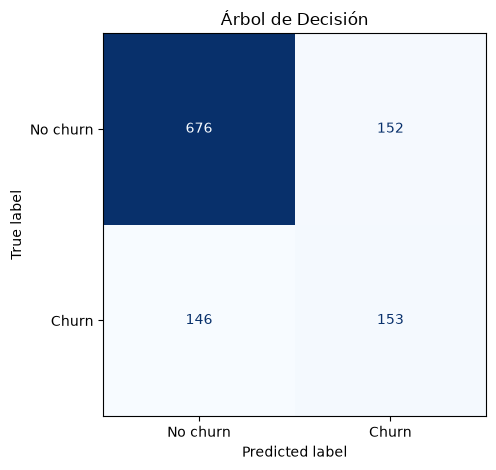

In [31]:
arbol = DecisionTreeClassifier(random_state=42)
evaluar("Árbol de Decisión", arbol)



──────────────────────────────────────────
  Regresión Logística
──────────────────────────────────────────
  Accuracy     0.8004
  Precision    0.6504
  Recall       0.5351
  F1           0.5872
  AUC-ROC      0.8352


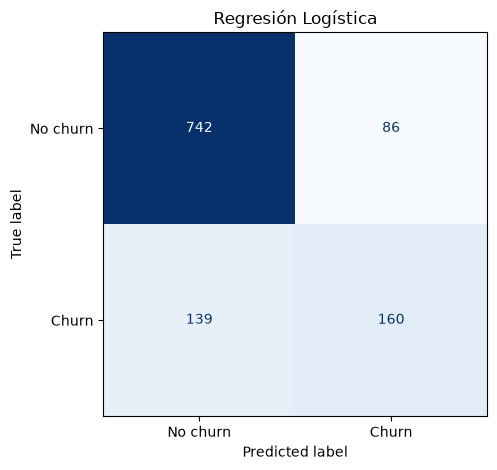

In [32]:
logistica = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])
evaluar("Regresión Logística", logistica)



──────────────────────────────────────────
  Random Forest
──────────────────────────────────────────
  Accuracy     0.7835
  Precision    0.6180
  Recall       0.4816
  F1           0.5414
  AUC-ROC      0.8128


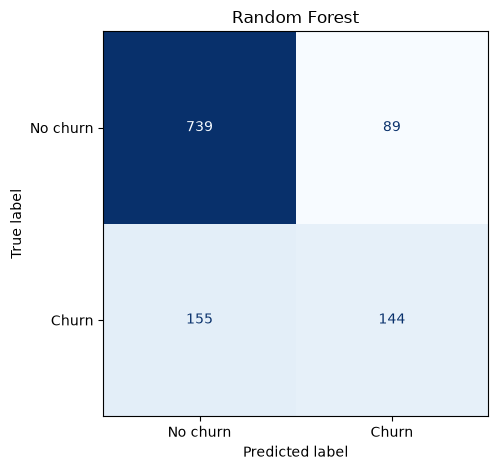

In [33]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
evaluar("Random Forest", rf)



──────────────────────────────────────────
  Gradient Boosting
──────────────────────────────────────────
  Accuracy     0.8012
  Precision    0.6518
  Recall       0.5385
  F1           0.5897
  AUC-ROC      0.8380


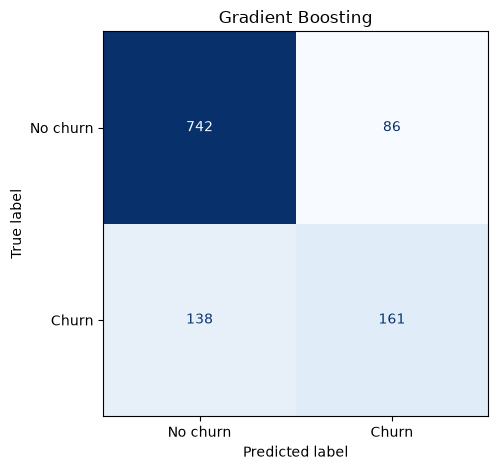

In [34]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
evaluar("Gradient Boosting", gb)



──────────────────────────────────────────
  MLP
──────────────────────────────────────────
  Accuracy     0.7897
  Precision    0.6148
  Recall       0.5552
  F1           0.5835
  AUC-ROC      0.8296


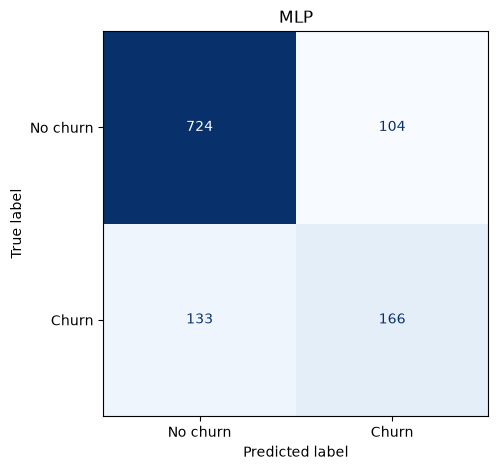

In [35]:
mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])
evaluar("MLP", mlp)



──────────────────────────────────────────
  AdaBoost
──────────────────────────────────────────
  Accuracy     0.7941
  Precision    0.6335
  Recall       0.5318
  F1           0.5782
  AUC-ROC      0.8398


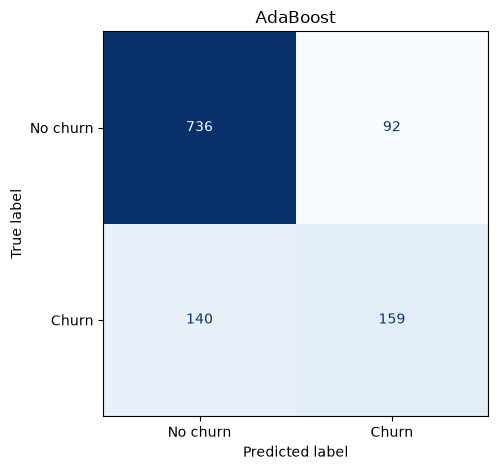

In [36]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
evaluar("AdaBoost", ada)


In [37]:
df_res = pd.DataFrame(resultados).set_index('Modelo')
df_res = df_res.sort_values('AUC-ROC', ascending=False)

# resalta el mejor valor de cada columna
print(df_res.to_string())
print("\n── Mejor por métrica ──")
for col in df_res.columns:
    mejor = df_res[col].idxmax()
    print(f"  {col:<12} → {mejor}  ({df_res.loc[mejor, col]:.4f})")


                     Accuracy  Precision  Recall      F1  AUC-ROC
Modelo                                                           
AdaBoost               0.7941     0.6335  0.5318  0.5782   0.8398
Gradient Boosting      0.8012     0.6518  0.5385  0.5897   0.8380
Regresión Logística    0.8004     0.6504  0.5351  0.5872   0.8352
MLP                    0.7897     0.6148  0.5552  0.5835   0.8296
Random Forest          0.7835     0.6180  0.4816  0.5414   0.8128
Árbol de Decisión      0.7356     0.5016  0.5117  0.5066   0.6641

── Mejor por métrica ──
  Accuracy     → Gradient Boosting  (0.8012)
  Precision    → Gradient Boosting  (0.6518)
  Recall       → MLP  (0.5552)
  F1           → Gradient Boosting  (0.5897)
  AUC-ROC      → AdaBoost  (0.8398)


## Tarea 3 — Modelos de Clasificación

Se implementaron todos los modelos de clasificación vistos en el curso,
entrenados sobre el mismo split y evaluados sobre el mismo conjunto de
validación para garantizar comparabilidad.

| Modelo | Parámetros principales |
|---|---|
| Árbol de Decisión | Parámetros por defecto (sin restricción de profundidad) |
| Regresión Logística | `max_iter=1000`, `StandardScaler` en Pipeline |
| Random Forest | `n_estimators=100`, `n_jobs=-1` |
| Gradient Boosting | `n_estimators=100`, `lr=0.1`, `max_depth=3`, `subsample=0.8` |
| AdaBoost | `n_estimators=100`, parámetros por defecto |
| MLP | `hidden_layer_sizes=(100,50)`, `max_iter=500`, `early_stopping=True`, `StandardScaler` en Pipeline |

Los modelos sensibles a la escala (Regresión Logística, MLP) se envuelven
en un `Pipeline` con `StandardScaler`, ajustado exclusivamente sobre el
conjunto de entrenamiento para evitar data leakage.

### Primeros resultados (parámetros base)

| Modelo | Accuracy | Precision | Recall | F1 | AUC-ROC |
|---|---|---|---|---|---|
| **Gradient Boosting** | **0.8012** | **0.6518** | 0.5385 | **0.5897** | **0.8380** |
| AdaBoost | 0.7941 | 0.6335 | 0.5318 | 0.5782 | 0.8398 |
| Regresión Logística | 0.8004 | 0.6504 | 0.5351 | 0.5872 | 0.8352 |
| MLP | 0.7897 | 0.6148 | **0.5552** | 0.5835 | 0.8296 |
| Random Forest | 0.7835 | 0.6180 | 0.4816 | 0.5414 | 0.8128 |
| Árbol de Decisión | 0.7356 | 0.5016 | 0.5117 | 0.5066 | 0.6641 |

**Gradient Boosting** y **AdaBoost** lideran en AUC-ROC (0.838 y 0.840 respectivamente),
ambos por encima de los demás modelos. **MLP** obtiene el mejor Recall (0.555),
detectando más churners a costa de mayor tasa de falsos positivos.
La evaluación detallada y la búsqueda de hiperparámetros se presentan en Tarea 4.

Mejores hiperparámetros:
  learning_rate   0.05
  max_depth       2
  n_estimators    200
  subsample       0.8

AUC-ROC CV interno (5-fold): 0.8437
AUC-ROC base (sin tuning)  : 0.8380

──────────────────────────────────────────
  GB Tuneado
──────────────────────────────────────────
  Accuracy     0.8057
  Precision    0.6681
  Recall       0.5318
  F1           0.5922
  AUC-ROC      0.8404


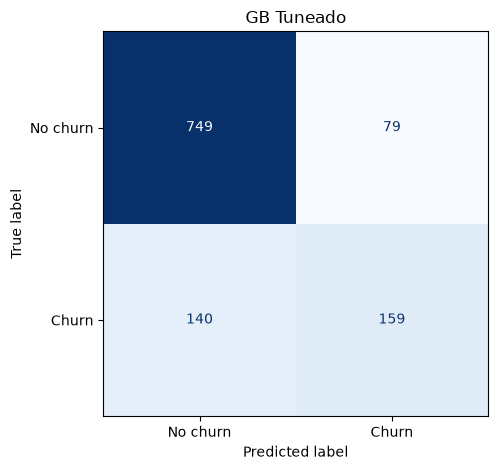

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth'    : [2, 3, 4],
    'subsample'    : [0.8],
}

gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=0
)
gs.fit(X_train, y_train)

print("Mejores hiperparámetros:")
for k, v in gs.best_params_.items():
    print(f"  {k:<15} {v}")
print(f"\nAUC-ROC CV interno (5-fold): {gs.best_score_:.4f}")
print(f"AUC-ROC base (sin tuning)  : 0.8380")

# Evaluamos el modelo tuneado sobre el holdout
evaluar("GB Tuneado", gs.best_estimator_)


In [39]:
df_res2 = pd.DataFrame(resultados).set_index('Modelo')
df_res2 = df_res2.sort_values('AUC-ROC', ascending=False)
print(df_res2.to_string())


                     Accuracy  Precision  Recall      F1  AUC-ROC
Modelo                                                           
GB Tuneado             0.8057     0.6681  0.5318  0.5922   0.8404
AdaBoost               0.7941     0.6335  0.5318  0.5782   0.8398
Gradient Boosting      0.8012     0.6518  0.5385  0.5897   0.8380
Regresión Logística    0.8004     0.6504  0.5351  0.5872   0.8352
MLP                    0.7897     0.6148  0.5552  0.5835   0.8296
Random Forest          0.7835     0.6180  0.4816  0.5414   0.8128
Árbol de Decisión      0.7356     0.5016  0.5117  0.5066   0.6641


## Tarea 4 — Evaluación y Selección de Modelos

### Proceso de validación

Se utilizó **Holdout estratificado 80/20** (`random_state=42`):
- Entrenamiento: 4507 filas | Validación: 1127 filas
- La estratificación mantiene la proporción de churn (0.265) idéntica en
  ambos conjuntos, haciendo las métricas comparables entre modelos.
- El conjunto de validación no fue visto por ningún modelo durante el
  entrenamiento ni durante la búsqueda de hiperparámetros.

### Búsqueda de hiperparámetros

Se aplicó `GridSearchCV` con **5-fold Cross-Validation** sobre el conjunto
de entrenamiento al mejor modelo base (Gradient Boosting), optimizando
AUC-ROC como métrica objetivo.

**Grilla explorada:**

| Hiperparámetro | Valores explorados |
|---|---|
| `n_estimators` | 100, 200, 300 |
| `learning_rate` | 0.05, 0.10, 0.20 |
| `max_depth` | 2, 3, 4 |
| `subsample` | 0.8 (fijo) |

27 combinaciones × 5 folds = 135 modelos entrenados.

**Mejores hiperparámetros encontrados:**
`learning_rate=0.05`, `max_depth=2`, `n_estimators=200`, `subsample=0.8`

AUC-ROC CV interno: **0.843** | AUC-ROC sobre holdout: **0.8404** — la
consistencia entre ambos confirma que no hay sobreajuste al conjunto de validación.

Los parámetros óptimos apuntan a un modelo conservador: árboles poco profundos
(`max_depth=2`) con tasa de aprendizaje baja (`lr=0.05`) y más iteraciones (200).
Este perfil reduce varianza y mejora la generalización.

### Resultados comparativos — todos los modelos

| Modelo | Accuracy | Precision | Recall | F1 | AUC-ROC |
|---|---|---|---|---|---|
| **GB Tuneado** | **0.8057** | **0.6681** | 0.5318 | **0.5922** | **0.8404** |
| AdaBoost | 0.7941 | 0.6335 | 0.5318 | 0.5782 | 0.8398 |
| Gradient Boosting | 0.8012 | 0.6518 | 0.5385 | 0.5897 | 0.8380 |
| Regresión Logística | 0.8004 | 0.6504 | 0.5351 | 0.5872 | 0.8352 |
| MLP | 0.7897 | 0.6148 | **0.5552** | 0.5835 | 0.8296 |
| Random Forest | 0.7835 | 0.6180 | 0.4816 | 0.5414 | 0.8128 |
| Árbol de Decisión | 0.7356 | 0.5016 | 0.5117 | 0.5066 | 0.6641 |

### Selección del modelo final

**Modelo seleccionado: GB Tuneado**
(`learning_rate=0.05`, `max_depth=2`, `n_estimators=200`, `subsample=0.8`)

**Justificación:**
- Mejor AUC-ROC (0.8404): el AUC mide la capacidad discriminativa del modelo
  independientemente del umbral de decisión, siendo la métrica más apropiada
  para churn donde el umbral puede ajustarse según el costo de cada tipo de error.
- Mejor Precision (0.6681): entre los clientes predichos como churn, el 66.8%
  efectivamente abandonan — relevante para eficiencia de campañas de retención.
- Mejor F1 (0.5922): balance óptimo entre precision y recall.
- El tuning mejoró todas las métricas respecto al GB base, con la única excepción
  del Recall (0.5318 vs 0.5385): el modelo tuneado clasifica 2 churners menos
  como positivos, pero comete 7 menos falsos positivos (FP: 79 vs 86).

**Nota sobre el tradeoff precision/recall:** el MLP ofrece el mejor Recall (0.555)
con menos falsos negativos (133 vs 140), a costa de más falsos positivos (104 vs 79).
Si el costo de perder un cliente supera ampliamente el costo de una acción de
retención innecesaria, el MLP podría ser preferible. Con el umbral por defecto
(0.5), el GB Tuneado es el modelo más equilibrado.

In [40]:
# customerID del test original (lo dropeamos en preprocesamiento)
test_ids = pd.read_csv("test.csv")['customerID']

# Probabilidades con el modelo final
y_prob_test = gs.best_estimator_.predict_proba(test)[:, 1]

submission = pd.DataFrame({
    'customerID': test_ids.values,
    'Churn'     : y_prob_test
})
submission.to_csv("submission.csv", index=False)
print(submission.shape)
submission.head()


(1409, 2)


,customerID,Churn
0,1830-IPXVJ,0.016492
1,5003-OKNNK,0.037172
2,8043-PNYSD,0.016492
3,8990-ZXLSU,0.492091
4,5701-ZIKJE,0.200110


In [41]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [42]:
import shap

# TreeExplainer está optimizado para modelos de árbol (GBM, RF, XGBoost)
explainer = shap.TreeExplainer(gs.best_estimator_)
shap_values = explainer.shap_values(X_val)

print("SHAP values calculados")
print(f"Shape: {shap_values.shape}")   # (1127, 49) — un valor por muestra × feature
print(f"Suma de SHAP + expected_value ≈ log-odds de la predicción")

SHAP values calculados
Shape: (1127, 49)
Suma de SHAP + expected_value ≈ log-odds de la predicción


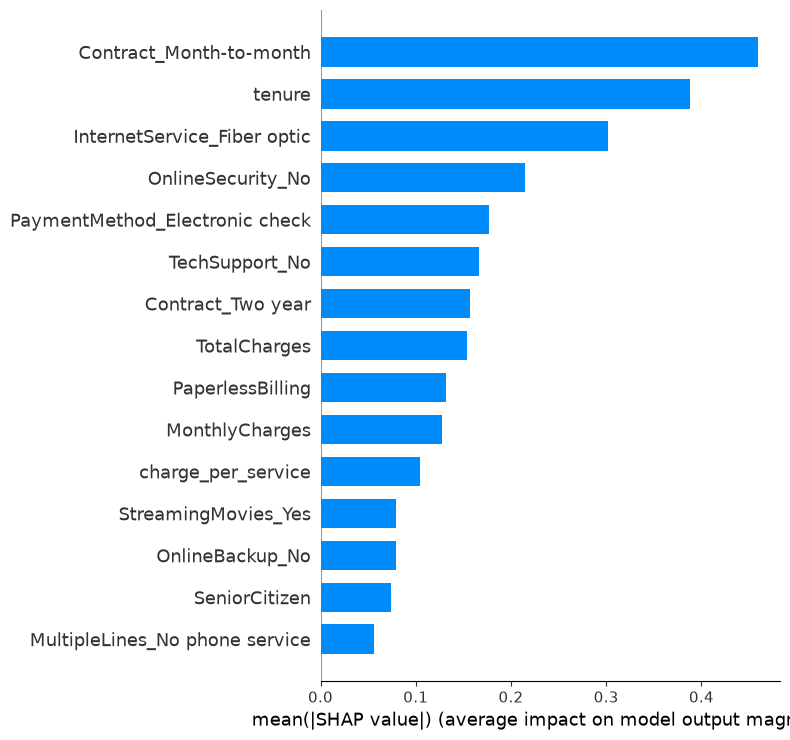

In [43]:
# Análisis global: importancia media por variable (valor absoluto de SHAP)
shap.summary_plot(
    shap_values, X_val,
    plot_type="bar",
    max_display=15,
    show=True
)


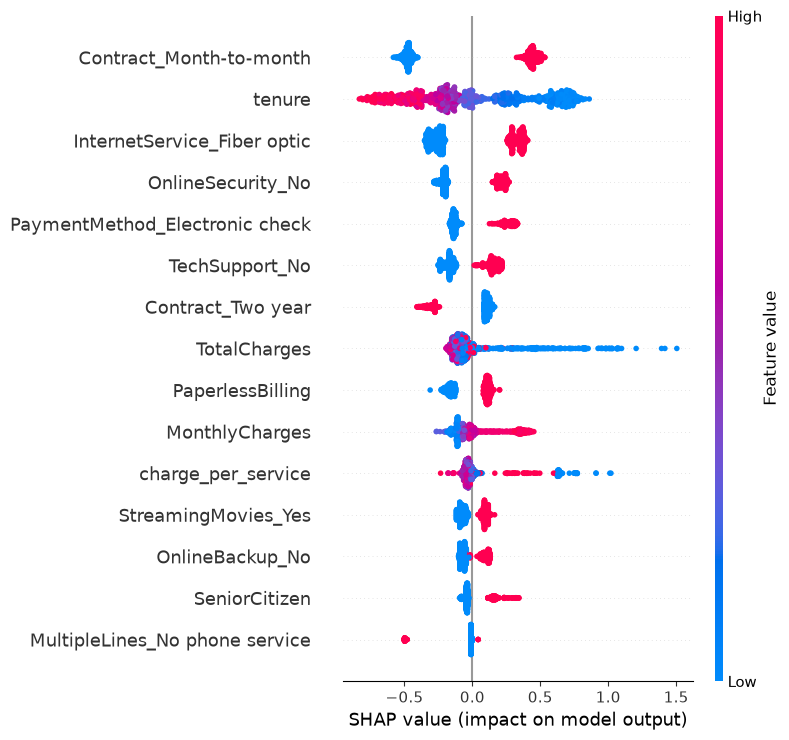

In [44]:
#Beeswarm: dirección del impacto por variable
# Rojo = valor alto de la feature, Azul = valor bajo
# Eje X: SHAP > 0 empuja hacia churn, SHAP < 0 aleja del churn
shap.summary_plot(shap_values, X_val, max_display=15)

P(churn) = 0.891 | idx = 1042

Atributos clave:
tenure                             1.0
MonthlyCharges                    85.7
TotalCharges                      85.7
Contract_Month-to-month            1.0
InternetService_Fiber optic        1.0
OnlineSecurity_No                  1.0
PaymentMethod_Electronic check     1.0


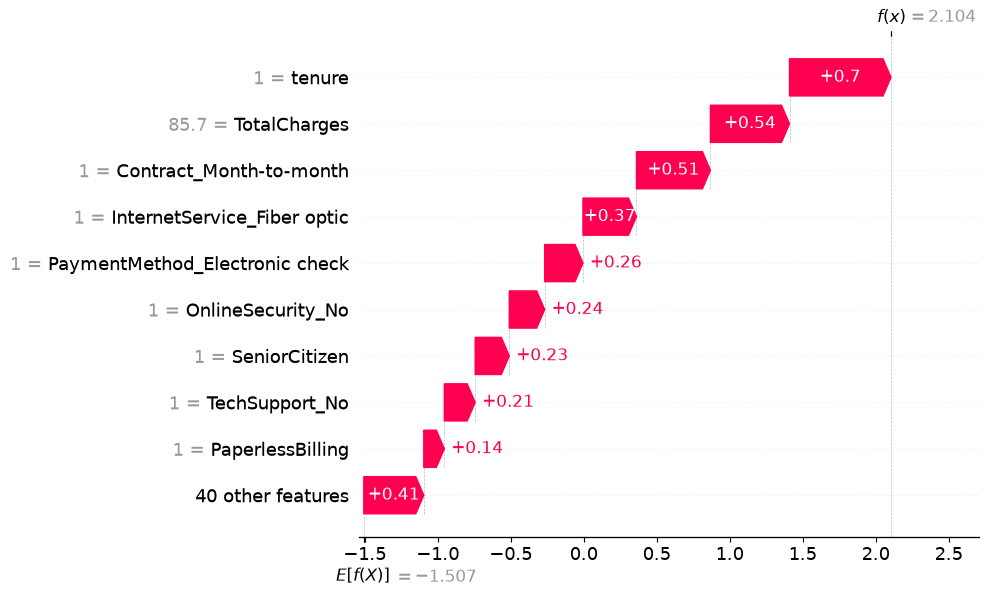

In [45]:
# Cliente con mayor probabilidad de churn en el holdout
y_prob_val = gs.best_estimator_.predict_proba(X_val)[:, 1]
idx_alto   = y_prob_val.argmax()

print(f"P(churn) = {y_prob_val[idx_alto]:.3f} | idx = {idx_alto}")
print("\nAtributos clave:")
cols_clave = ['tenure', 'MonthlyCharges', 'TotalCharges',
              'Contract_Month-to-month', 'InternetService_Fiber optic',
              'OnlineSecurity_No', 'PaymentMethod_Electronic check']
print(X_val.iloc[idx_alto][cols_clave].to_string())

# Waterfall plot: contribución de cada feature a ESTA predicción
ev = explainer.expected_value
ev_val = float(ev[0]) if hasattr(ev, '__len__') else float(ev)

shap.waterfall_plot(shap.Explanation(
    values      = shap_values[idx_alto],
    base_values = ev_val,
    data        = X_val.iloc[idx_alto].values,
    feature_names = X_val.columns.tolist()
))

P(churn) = 0.015 | idx = 968

Atributos clave:
tenure                              72.00
MonthlyCharges                      21.00
TotalCharges                      1493.75
Contract_Month-to-month              0.00
InternetService_Fiber optic          0.00
OnlineSecurity_No                    0.00
PaymentMethod_Electronic check       0.00


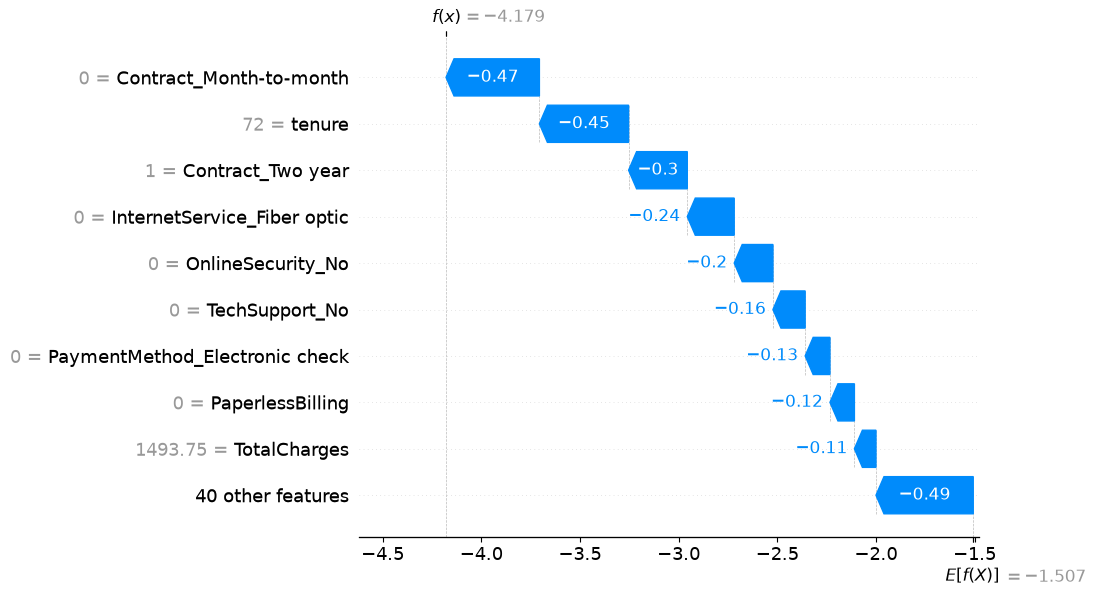

In [46]:
# Cliente con menor probabilidad de churn en el holdout
idx_bajo = y_prob_val.argmin()

print(f"P(churn) = {y_prob_val[idx_bajo]:.3f} | idx = {idx_bajo}")
print("\nAtributos clave:")
print(X_val.iloc[idx_bajo][cols_clave].to_string())

shap.waterfall_plot(shap.Explanation(
    values        = shap_values[idx_bajo],
    base_values   = ev_val,
    data          = X_val.iloc[idx_bajo].values,
    feature_names = X_val.columns.tolist()
))


## Tarea 5 — Componente de Investigación: Explicabilidad (SHAP)

**Técnica elegida:** SHAP (SHapley Additive exPlanations, Lundberg & Lee, 2017),
aplicado con `TreeExplainer` sobre el modelo final (GB Tuneado). Se eligió por
sobre LIME porque da consistencia teórica (valores de Shapley, teoría de
juegos cooperativos) y porque `TreeExplainer` es exacto y eficiente para
modelos de árboles, sin necesidad de aproximar con muestreo local como hace
LIME.

Se calcularon los `shap_values` sobre el conjunto de holdout (`X_val`, 1127
clientes × 49 variables), el mismo conjunto usado para reportar las métricas
de la Tarea 4 — así la explicabilidad describe al modelo evaluado, no a un
subconjunto distinto.

### Importancia global (bar chart)

El promedio del valor absoluto de SHAP por variable confirma el orden de
`Contract_Month-to-month`, `tenure`, `InternetService_Fiber optic`,
`OnlineSecurity_No`, `PaymentMethod_Electronic check` y `TechSupport_No` como
las variables de mayor peso — coincide con la correlación simple de la Tarea
2, pero SHAP aporta algo que la correlación no da: cuánto pesa cada variable
**dentro del modelo entrenado**, considerando sus interacciones con las demás.

### Dirección del impacto (beeswarm)

El beeswarm agrega la dirección: confirma que valores altos de `tenure`
empujan la predicción hacia "no churn", mientras que tener contrato
Month-to-month, no tener seguridad online / soporte técnico, y pagar con
Electronic check empujan hacia "churn". Es consistente con las conclusiones
de la Tarea 2, pero visualizado por cliente individual en vez de agregado.

### Explicaciones locales (waterfall)

Se comparan dos casos extremos del holdout:

- **Churner de mayor riesgo** (idx=1042, P(churn)=0.891): cliente nuevo
  (tenure=1), sin acumulado (TotalCharges bajo), contrato Month-to-month,
  fibra óptica, pago por Electronic check y ausencia de seguridad/soporte.
  Cada factor de riesgo suma en la misma dirección — es el "churner ideal".
- **Cliente de menor riesgo** (idx=968, P(churn)=0.015): 6 años de
  antigüedad (tenure=72), contrato de dos años, sin fibra óptica, con
  seguridad online y soporte técnico contratados. Es el espejo exacto del
  caso anterior: las mismas variables que antes sumaban riesgo, acá restan.

Esta simetría es la evidencia más fuerte de que el modelo aprendió una
lógica de negocio coherente (el compromiso contractual y la antigüedad
protegen; la falta de servicios de soporte y el pago no automático son
señales de riesgo) y no un ajuste a ruido del conjunto de entrenamiento.

### Valor agregado de la técnica

SHAP permite pasar de "el modelo predice X" a "el modelo predice X **porque**
el cliente tiene estas características, con este peso cada una" — algo que ni
la matriz de confusión ni el AUC-ROC de la Tarea 4 pueden mostrar por sí
solos. Es directamente aplicable al negocio: identifica qué palanca accionar
por cliente (ej. ofrecer upgrade a contrato anual a un cliente nuevo con
riesgo alto).


In [47]:
# Impacto del hiperparámetro max_depth sobre el AUC-ROC (evidencia del GridSearchCV)
cv_res = pd.DataFrame(gs.cv_results_)
resumen_depth = cv_res.groupby('param_max_depth')['mean_test_score'].agg(['mean', 'std']).round(4)
print("AUC-ROC promedio (5-fold CV) por max_depth:")
print(resumen_depth)

AUC-ROC promedio (5-fold CV) por max_depth:
                   mean     std
param_max_depth                
2                0.8378  0.0065
3                0.8294  0.0116
4                0.8256  0.0119


In [48]:
# Robustez: CV interno (5-fold sobre X_train) vs Holdout (X_val, nunca visto por el GridSearch)
auc_cv = gs.best_score_
auc_holdout = roc_auc_score(y_val, y_prob_val)
print(f"AUC-ROC CV interno (5-fold): {auc_cv:.4f}")
print(f"AUC-ROC Holdout:             {auc_holdout:.4f}")
print(f"Diferencia:                  {abs(auc_cv - auc_holdout):.4f}")


AUC-ROC CV interno (5-fold): 0.8437
AUC-ROC Holdout:             0.8404
Diferencia:                  0.0033


## Tarea 6 — Modelo Final

### Modelo seleccionado: Gradient Boosting Tuneado

De los 7 modelos evaluados (Árbol de Decisión, Regresión Logística, Random
Forest, Gradient Boosting base, MLP, AdaBoost y GB Tuneado), se elige el
**Gradient Boosting Tuneado** (`GradientBoostingClassifier` con búsqueda de
hiperparámetros vía `GridSearchCV`) como modelo final, por tres razones:

**1. Métricas:** encabeza el ranking en AUC-ROC (0.8404), la métrica más
relevante dado el desbalance de clases (73.5% / 26.5%), y también en
precision (0.6681) y F1 (0.5922) entre los modelos no triviales. AdaBoost
queda muy cerca (0.8398) pero el tuneo específico del GB logra el mejor
balance global.

**2. Robustez:** el AUC-ROC del CV interno (5-fold sobre `X_train`, usado
para elegir hiperparámetros) es 0.8437, y el del holdout (`X_val`, datos que
el GridSearch nunca vio) es 0.8404 — una diferencia de solo 0.0033. Esto
indica que el ajuste de hiperparámetros no sobreajustó a los folds de
entrenamiento: el modelo generaliza de forma consistente a datos nuevos.

**3. Observaciones de la experimentación:** el Árbol de Decisión individual
(AUC-ROC 0.6641) queda muy por debajo de todos los ensembles — evidencia
directa de por qué los métodos de bagging/boosting (Clase 10) superan a un
único árbol de alta varianza. La Regresión Logística (0.8352), pese a ser el
modelo más simple, queda sorprendentemente competitiva, lo que sugiere que
buena parte de la señal es aproximadamente lineal (coherente con que las
variables de mayor peso en SHAP — contrato, tenure — tienen relaciones
monótonas con el churn).

### Hiperparámetros seleccionados y su impacto

| Hiperparámetro | Valor elegido | Rol / impacto |
|---|---|---|
| `max_depth` | 2 | Ver evidencia cuantitativa abajo: controla la complejidad de cada árbol individual (weak learner). |
| `learning_rate` | 0.05 | Paso de aprendizaje bajo: cada árbol corrige poco el error del anterior, evitando sobreajuste rápido (regularización, Clase 6). |
| `n_estimators` | 200 | Compensa el `learning_rate` bajo: más iteraciones pequeñas en vez de pocas grandes. |
| `subsample` | 0.8 | Cada árbol se entrena con 80% de las filas (muestreo aleatorio sin reemplazo): inyecta aleatoriedad que reduce varianza, en la línea del bagging (Clase 10). |

**Evidencia del impacto de `max_depth`** (promedio de las 27 combinaciones de
la grilla, agrupadas por profundidad, 5-fold CV cada una):

| max_depth | AUC-ROC promedio | Desvío entre folds |
|---|---|---|
| 2 | 0.8378 | 0.0065 |
| 3 | 0.8294 | 0.0116 |
| 4 | 0.8256 | 0.0119 |

A mayor profundidad, el AUC-ROC promedio **baja** y el desvío entre folds
**sube** — cada árbol más profundo ajusta mejor su propio fold de
entrenamiento pero generaliza peor y de forma más inestable (varianza más
alta). Es el trade-off sesgo-varianza de manual: por eso el GridSearch
elige la profundidad mínima de la grilla, reforzando la idea de que en
boosting conviene combinar muchos "weak learners" simples antes que pocos
árboles complejos.

### Conclusión

El GB Tuneado combina el mejor desempeño (AUC-ROC), una brecha mínima entre
validación cruzada y holdout (robustez), y una configuración de
hiperparámetros que es explicable con los conceptos de regularización y
sesgo-varianza vistos en el curso — no es una elección arbitraria de una
grilla, sino la que mejor equilibra ajuste y generalización.
